# 🚢 ITDS251 ML Midterm Practice 2 — Titanic Classification

> โจทย์นี้คือ **Classification (ทายผลว่าผู้โดยสาร รอดตาย (1) หรือ ไม่รอด (0))**
> ฐานข้อมูล: Titanic (คลาสสิกสุดๆ ของคนเรียน ML)

---

## 📦 Part 1: Imports

In [125]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


---
## 📊 Part 2: อ่านข้อมูลจาก Internet & สำรวจข้อมูล

In [126]:
# อ่านไฟล์ CSV จาก URL (โหลดเข้า RAM โดยตรง)
url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df = pd.read_csv(url)


In [127]:
# ดู 5 แถวแรก
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [128]:
# ดูว่ามีคอลัมน์อะไรบ้าง และข้อมูลเป็นประเภทไหน (info)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [129]:
# เช็ค Missing Value ว่ามีคอลัมน์ไหนหายไปกี่ช่อง
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

---
## 🧹 Part 3: Data Cleaning

ข้อมูล Titanic มักจะหายไปในคอลัมน์: `Age` (อายุ), `Cabin` (ห้องพัก), `Embarked` (ท่าเรือที่ขึ้น)

In [130]:
# 1. ลบคอลัมน์ที่ไม่จำเป็นต่อการทำนายออก
# เช่น PassengerId, Name ทิ้งไปเลย (และ Ticket กับ Cabin ข้อมูลหายเยอะเกินไป เลยจะลบทิ้งด้วย)
# Hint: df.drop([list ชื่อคอลัมน์], axis=1, inplace=True)
df.drop(["PassengerId","Name","Ticket","Cabin"],axis = 1 , inplace=True)

In [131]:
# 2. เติม Missing Value ในคอลัมน์ อายุ (Age) ด้วย **ค่าเฉลี่ย** (median หรือ mean ก็ได้ สมมติใช้ median)
# Hint: df["Age"].fillna(...)
df["Age"].fillna(df["Age"].median(),inplace=True)

C:\Users\User\AppData\Local\Temp\ipykernel_49920\1126839330.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Age"].fillna(df["Age"].median(),inplace=True)


In [132]:
# 3. เติม Missing Value ในคอลัมน์ จุดขึ้นรถ (Embarked) ด้วย **โหมด** (ค่าที่ซ้ำบ่อยสุด)
# (เนื่องจาก Embarked เป็น "S", "C", "Q")
df["Embarked"].fillna(df["Embarked"].mode()[0], inplace=True)


C:\Users\User\AppData\Local\Temp\ipykernel_49920\3442616860.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Embarked"].fillna(df["Embarked"].mode()[0], inplace=True)


In [133]:
# 4. เช็ค Missing Value อีกรอบ ว่าเหลือ 0 หมดหรือยัง
df.isnull().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

---
## 📈 Part 4: Data Visualization (วิเคราะห์ด้วยภาพ)

<Axes: xlabel='Survived', ylabel='count'>

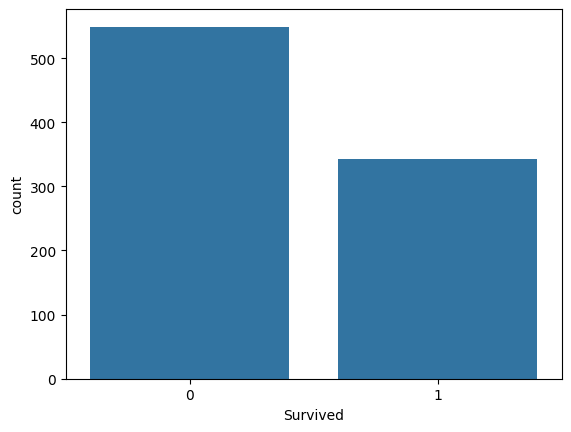

In [134]:
# สร้าง Countplot ดูสัดส่วนคน รอด (Survived = 1) กับ ไม่รอด (Survived = 0)
sns.countplot(x='Survived',data=df)

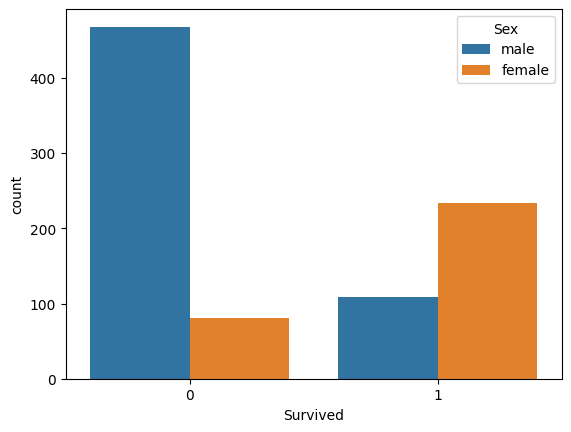

In [135]:
# สร้าง Countplot ดูคนรอด/ไม่รอด โดยแบ่งสีตาม 'Sex' (เพศ)
# Hint: sns.countplot(data=df, x='Survived', hue='Sex')
sns.countplot(data=df, x='Survived', hue='Sex')
plt.show()

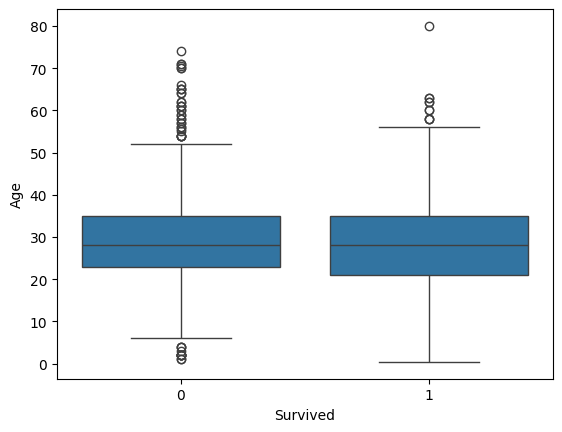

In [136]:
# สร้าง Boxplot ดูความสัมพันธ์ระหว่าง อายุ (Age) กับการรอดชีวิต (Survived)
# Hint: sns.boxplot.(data=df, x='Survived', y='Age')
sns.boxplot(data=df, x='Survived', y='Age')
plt.show()

---
## 🔧 Part 5: Feature Engineering (แปลงข้อมูลตัวอักษรเป็นตัวเลข)

In [137]:
# 1. ใช้ LabelEncoder แปลงคอลัมน์เพศ (Sex) จาก male/female เป็น 0/1
from sklearn.preprocessing import LabelEncoder

# ลองเขียนเรียกใช้ LabelEncoder ด้วยตัวเอง
le= LabelEncoder()
df["Sex"]= le.fit_transform(df["Sex"])

In [138]:
# 2. ใช้ pd.get_dummies() ทำ One-Hot Encoding คอลัมน์ท่าเรือ ('Embarked')
# แปลงเสร็จแล้วเซฟทับตัวแปร df เหมือนเดิม
df = pd.get_dummies(df,columns=["Embarked"])

---
## 🎯 Part 6: Train-Test Split & Scaling

In [139]:
# แยก Features (X) กับ Target (y)
# ข้อนี้ Target (คำตอบ) ของเราคือคอลัมน์ชื่ออะไร? ไปใส่ใน y ได้เลย
X = df.drop("Survived",axis=1)# Features = ทุกคอลัมน์ยกเว้น target
y = df["Survived"]# Target = คอลัมน์ที่ต้องการทำนาย


In [140]:
# แบ่ง Train 80% / Test 20%
from sklearn.model_selection import train_test_split

# เขียนเองเลย:
X_train, X_test, y_train, y_test= train_test_split(
    X, y,
test_size=0.2,# 20% เป็น test
random_state=42# ให้ผลคงที่ทุกครั้ง
)

In [141]:
# ทำ StandardScaler ให้กับข้อมูล X_train, X_test
from sklearn.preprocessing import StandardScaler
scaler= StandardScaler()
X_train_scaled= scaler.fit_transform(X_train)# fit + transform กับ train
X_test_scaled= scaler.transform(X_test)# transform อย่างเดียวกับ test


---
## 🤖 Part 7: Classification Models
ข้อนี้เราจะทำนาย "หมวดหมู่" แล้ว (รอด=1, ตาย=0) ฉะนั้นใช้ Regressor ไม่ได้แล้วนะ!

In [142]:
# 7.1 Logistic Regression
from sklearn.linear_model import LogisticRegression

# สร้าง -> fit (ใช้ตัว scaled) -> predict
model= LogisticRegression(max_iter=1000,random_state=42)
model.fit(X_train_scaled, y_train)
y_pred= model.predict(X_test_scaled)

In [143]:
# Evaluate Logistic Regression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


0.8100558659217877
              precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179

[[90 15]
 [19 55]]


In [144]:
# 7.2 Decision Tree Classifier
from sklearn.tree import DecisionTreeClassifier

# ห้ามลืม! Decision Tree ไม่สนใจเรื่อง data scale จะเอาตัว X_train ดิบๆ หรือ scaled มาใส่ก็ได้ ผลเท่ากัน
model= DecisionTreeClassifier(max_depth=3,random_state=42)
model.fit(X_train, y_train)# ❌ ไม่ต้อง scale
y_pred= model.predict(X_test)

In [145]:
# 7.3 Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier

model= RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)
y_pred= model.predict(X_test)

# ดู Feature Importance
importances= model.feature_importances_
for name, imp in zip(X.columns, importances):
    print(f"{name}:{imp:.4f}")

Pclass:0.0930
Sex:0.2805
Age:0.2456
SibSp:0.0500
Parch:0.0339
Fare:0.2607
Embarked_C:0.0120
Embarked_Q:0.0077
Embarked_S:0.0166


In [146]:
# 7.4 Support Vector Classification (SVC)
from sklearn.svm import SVC

# SVC *ต้อง* ใช้ข้อมูลที่สเกล (X_train_scaled) นะครับ!
model= SVC(kernel='rbf',random_state=42)# kernel: 'linear', 'rbf', 'poly'
model.fit(X_train_scaled, y_train)# ⚠️ ต้อง scale
y_pred= model.predict(X_test_scaled)

In [147]:
# 7.5 k-NN Classifier (n_neighbors=5)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

# k-NN *ต้อง* ใช้ข้อมูลที่สเกลเหมือนกัน

model= KNeighborsClassifier(n_neighbors=5)# k=5 (จำนวนเพื่อนบ้าน)
model.fit(X_train_scaled, y_train)# ⚠️ ต้อง scale ก่อน!
y_pred= model.predict(X_test_scaled)

# หา k ที่ดีที่สุดด้วย Cross-Validation
best_k=3
best_score=0
for k in range(1,21):
    knn= KNeighborsClassifier(n_neighbors=k)
    scores= cross_val_score(knn, X_train_scaled, y_train,cv=5)
    if scores.mean()> best_score:
        best_score= scores.mean()
        best_k= k
print(f"Best k ={best_k}, Score ={best_score:.4f}")

Best k =12, Score =0.8202


---
## 🧠 Part 8: Deep Learning (Binary Classification)
รอด / ไม่รอด มีแค่ 2 คำตอบ เราเรียกว่า **Binary Classification**

In [148]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

# สร้างโครงข่าย Neural Network
# - ใช้ Sequential()
# - Hidden Layer สัก 2 ชั้น (ยัด Dense(32, activation='relu') กับ Dropout(0.2))
# - Output Layer ต้องเป็นแบบไหนสำหรับ 2 หมวดหมู่?
model= Sequential()
model.add(Dense(64,activation='relu',input_shape=(X_train.shape[1],)))# hidden layer 1
model.add(Dropout(0.3))# Dropout 30% ป้องกัน overfitting
model.add(Dense(32,activation='relu'))# hidden layer 2
model.add(Dense(1, activation='sigmoid'))# output layer (regression = 1 node, ไม่ใส่ activation)

# ดูโครงสร้างโมเดล
model.summary()

c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 64)             │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,753 (10.75 KB)

 Trainable params: 2,753 (10.75 KB)

 Non-trainable params: 0 (0.00 B)

In [149]:
# สั่ง Compile โมเดล
# - loss ต้องใช้ตัวไหน? ('mse' หรือ 'binary_crossentropy' หรือ 'categorical_crossentropy')
# === สำหรับ Binary Classification ===
model.compile(
optimizer='adam',
loss='binary_crossentropy',
metrics=['accuracy']
)
# output layer: Dense(1, activation='sigmoid')

In [150]:
# สั่ง Train (fit) โมเดล
# ใช้ X_train_scaled นะครับ
# epochs=50, batch_size=32, validation_split=0.2
history= model.fit(
    X_train_scaled, y_train,
epochs=50,# จำนวนรอบเทรน
batch_size=32,# จำนวนตัวอย่างต่อ batch
validation_split=0.2,# แบ่ง 20% จาก train เป็น validation
verbose=1
)

Epoch 1/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6591 - loss: 0.6454 - val_accuracy: 0.7692 - val_loss: 0.5564
Epoch 2/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7364 - loss: 0.5672 - val_accuracy: 0.8112 - val_loss: 0.4898
Epoch 3/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7663 - loss: 0.5185 - val_accuracy: 0.8182 - val_loss: 0.4540
Epoch 4/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7821 - loss: 0.4951 - val_accuracy: 0.8112 - val_loss: 0.4357
Epoch 5/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7821 - loss: 0.4929 - val_accuracy: 0.8042 - val_loss: 0.4270
Epoch 6/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7891 - loss: 0.4701 - val_accuracy: 0.8112 - val_loss: 0.4174
Epoch 7/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8049 - loss: 0.4609 - val_accuracy: 0.8042 - val_loss: 0.4148
Epoch 8/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8049 - loss: 0.4571 - val_accuracy: 0.8182 - val_loss:

In [151]:
# สั่ง Predict (Deep Learning จะทำนายพ่นเลขความน่าจะเป็น 0.0 - 1.0 กลับมา)
y_pred_prob = model.predict(X_test_scaled)
# แปลงกลับให้เป็น 0/1 (ถ้าความน่าจะเป็นมากกว่า 0.5 ให้เป็น 1, น้อยกว่า 0.5 ให้เป็น 0)
y_pred_dl = (y_pred_prob > 0.5).astype(int)

# Classification (ได้ probability → ต้องแปลง)
# y_pred_prob= model.predict(X_test_scaled)
# y_pred= np.argmax(y_pred_prob,axis=1)# เลือก class ที่ probability สูงสุด

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


In [152]:
# วัดผลความแม่นยำ (Accuracy) ของ Deep Learning
from sklearn.metrics import accuracy_score
acc = accuracy_score(y_test, y_pred)
print(f"Deep Learning Accuracy: {acc:.4f}")

Deep Learning Accuracy: 0.8045
